In [1]:
## analyze data saved with the lab jack
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import scipy.signal as sp
from scipy.optimize import curve_fit

In [2]:
### first, compare PSDs for some data set (curr_files) to some ref set (ref_files)

data_dir = "/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250328/"

# ## Files for 25-35 Hz noise drive
# curr_files = glob(data_dir + 
#'transfer_func_data_UV_1658_noise_0.086Hz_20.000V_5.83e-07mbar.npz')
#"transfer_func_data_sin_noise_filament_4_0.086Hz_20.000V_8.52e-06mbar.npz")
#"transfer_func_data_noise_UV_3_0.086Hz_20.000V_4.92e-07mbar.npz") 
#transfer_func_data_noise_0.086Hz_20.000V_4.63e-07mbar.npz")
ref_files = glob(data_dir + 'transfer_func_data_noise_*.npz')
# 'transfer_func_data_sin_noise_UV_2_0.086Hz_20.000V_8.41e-07mbar.npz')
# "transfer_func_data_noise_UV_2_0.086Hz_20.000V_4.94e-07mbar.npz")

# ## Compare 1-50 Hz and 0.5-25 Hz drive
curr_files = glob('/Users/mollywatts/Library/CloudStorage/OneDrive-Personal/VSCode/1_8_mbar_0106_data/*.npz') #glob(data_dir + "transfer_func_data_UV_*.npz")
# ref_files = glob(data_dir + "transfer_func_data_noise_0.050Hz_20.000V*.npz")

nperseg = 2**14

channel_list = ['x', 'y', 'Sum', 'Drive']

print("Found %d current files and %d reference files" % (len(curr_files), len(ref_files)))

Found 3 current files and 3 reference files


In [4]:
# Example: load the first file
file_path = ref_files[0]

# Load the .npz file
data = np.load(file_path)

# List the arrays stored in the file
print("Keys in the file:", data.files)

# Optionally, access and inspect one array
for key in data.files:
    print(f"{key}: shape = {data[key].shape}, dtype = {data[key].dtype}")
    print("Sampling rate Fs:", data['Fs'])
    print("Pressure data:", data['pressure_data'])
    # print(t)


Keys in the file: ['data', 'Fs', 'noise_playback_freq', 'synth_amplitude', 'pressure_data']
data: shape = (10, 16384, 4), dtype = float64
Sampling rate Fs: 1000
Pressure data: [4.68e-07 4.70e-07]
Fs: shape = (), dtype = int32
Sampling rate Fs: 1000
Pressure data: [4.68e-07 4.70e-07]
noise_playback_freq: shape = (), dtype = float64
Sampling rate Fs: 1000
Pressure data: [4.68e-07 4.70e-07]
synth_amplitude: shape = (), dtype = int32
Sampling rate Fs: 1000
Pressure data: [4.68e-07 4.70e-07]
pressure_data: shape = (2,), dtype = float64
Sampling rate Fs: 1000
Pressure data: [4.68e-07 4.70e-07]


In [5]:
Fs = data['Fs'].item()
num_samples = data['data'].shape[1]
# Time vector for one segment
t = np.arange(num_samples) / Fs
print(t)

[0.0000e+00 1.0000e-03 2.0000e-03 ... 1.6381e+01 1.6382e+01 1.6383e+01]


In [14]:
def make_psd_from_file_list(files):
    psd_dict = {}
    n_psds = 0

    for ch in channel_list:
        psd_dict[ch] = None

    for f in files:
        data = np.load(f)

        curr_pressures = data['pressure_data']
        #print("Start/End pressures: %.2e, %.2e" % (curr_pressures[0], curr_pressures[-1]))
    
        for meas in range(len(data['data'])):
            curr_data = data['data'][meas]

            ## ignore the file if the y data drifted out of range
            if(np.abs(np.median(curr_data[:, 1])) > 3):
                #print("Skipping trace for file %s, y data drifted out of range" % f)
                continue

            n_psds += 1

            for ch_idx, ch in enumerate(channel_list):
                freqs, cpsd = sp.welch(curr_data[:,ch_idx], nperseg=nperseg, fs=data['Fs'])

                if(psd_dict[ch] is None):
                    psd_dict[ch] = cpsd
                else:
                    psd_dict[ch] += cpsd

    if(n_psds == 0):
        return None, None

    for ch in channel_list:
        psd_dict[ch] /= n_psds

    return psd_dict, freqs

In [15]:
def plot_psd_dict(psd_dict, freqs, fig, xlims=[0, 55], lc=None):
    plt.figure(fig.number)
    for ch in channel_list:
        plt.subplot(1, len(channel_list), channel_list.index(ch)+1)
        plt.title(ch)
        if lc is not None:
            plt.semilogy(freqs, psd_dict[ch], color=lc)
        else:
            plt.semilogy(freqs, psd_dict[ch])
        plt.xlim(xlims[0], xlims[1])
        plt.xlabel("Frequency (Hz)")

    plt.subplot(1, len(channel_list), 1)        
    plt.ylabel("PSD [V$^2$/Hz]")
    

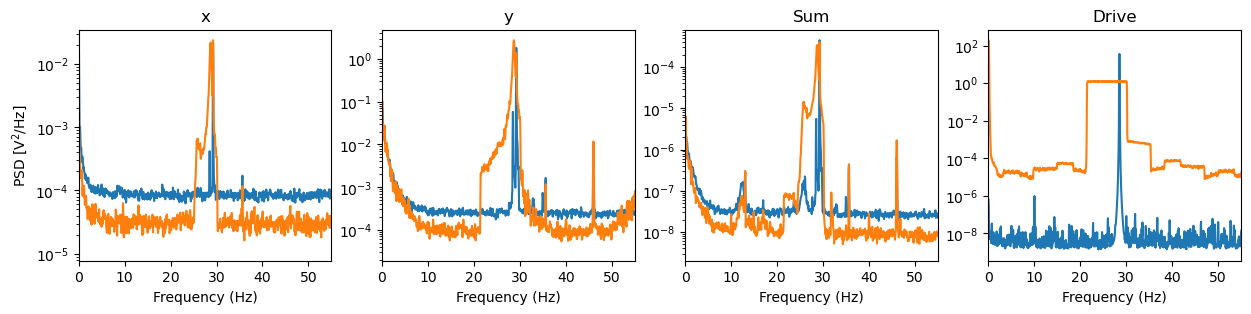

In [16]:
curr_psd_dict, curr_freqs = make_psd_from_file_list(curr_files)
ref_psd_dict, ref_freqs = make_psd_from_file_list(ref_files)

fig = plt.figure(figsize=(15,3))
plot_psd_dict(curr_psd_dict, curr_freqs, fig)
plot_psd_dict(ref_psd_dict, ref_freqs, fig)

plt.show()

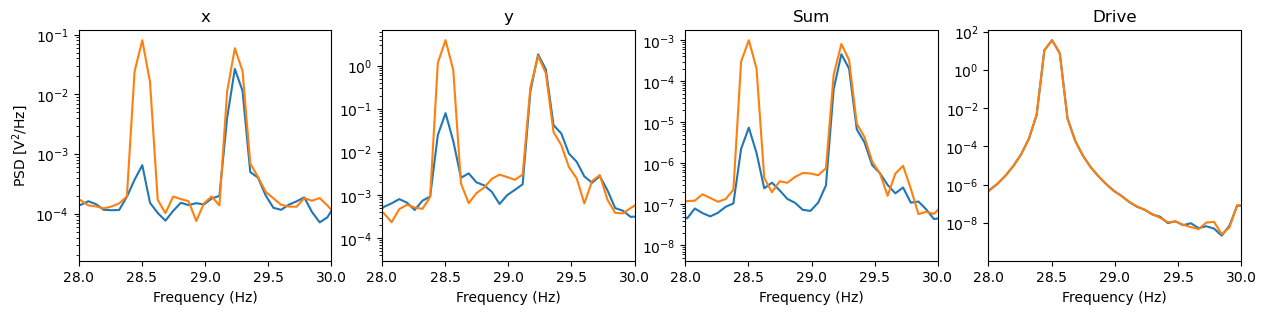

In [13]:
curr_psd_dict, curr_freqs = make_psd_from_file_list(curr_files)
ref_psd_dict, ref_freqs = make_psd_from_file_list(ref_files)

fig = plt.figure(figsize=(15,3))
plot_psd_dict(curr_psd_dict, curr_freqs, fig)
plot_psd_dict(ref_psd_dict, ref_freqs, fig, xlims=[28,30])

plt.show()

In [8]:
### same as above, but make the sweep versus pressure with no reference

pressure_data_dir = "/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250328/"

pressure_files = glob(pressure_data_dir + "transfer_func_data_UV_*.npz") #noise_0.*Hz_20.000V_*mbar.npz")

## write a regex to extract the pressure from the file name
pressure_list = []
for f in pressure_files:
    pressure_list.append(float(f.split("_")[-1].replace("mbar.npz", "")))

pressure_sort_idx = np.argsort(pressure_list)
pressure_files = np.array(pressure_files)[pressure_sort_idx]
pressure_list = np.array(pressure_list)[pressure_sort_idx]

print("Found %d pressure files with pressures:" % (len(pressure_files)))
print(pressure_list)

## get colormap in pressure order
n_colors = len(pressure_files)
colors = plt.cm.jet(np.linspace(0, 1, n_colors))

Found 10 pressure files with pressures:
[5.83e-07 5.91e-07 5.93e-07 6.04e-07 6.15e-07 6.34e-07 6.46e-07 6.78e-07
 7.46e-07 9.79e-07]


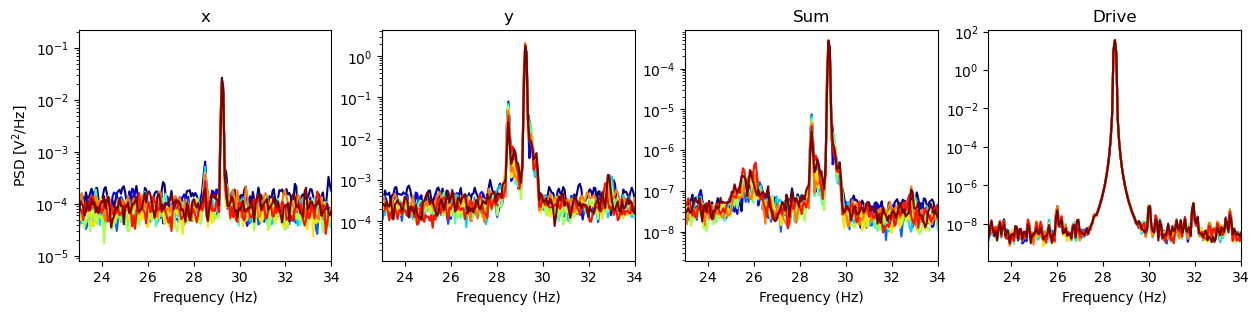

In [9]:
fig = plt.figure(figsize=(15,3))

nperseg = 2**14

for p, pf, c in zip(pressure_list, pressure_files, colors):
    curr_psd_dict, curr_freqs = make_psd_from_file_list([pf])
    if curr_psd_dict is None:
        continue
    plot_psd_dict(curr_psd_dict, curr_freqs, fig, xlims=[23,34], lc=c)

In [10]:
def lorentzianPSD(f, A, f0, gamma):
    omega = 2*np.pi*f
    omega0 = 2*np.pi*f0
    gamma = 2*np.pi*gamma
    return A / ((omega**2-omega0**2)**2 + omega**2 * gamma**2) 

In [11]:
def fit_psd(psd, freqs, fig=None, make_plot=False, ch='y', xlims=[0, 55], 
            lc=None, ylims=[1e-6,1], fit_range=[26, 31], noise_freqs=[], 
            subplot_idx = [], guess_params=[1e3, 29, 1], plot_guess=False,
            plot_label=""):

    """ Fit a lorentzian to the PSD data
        Args:
            psd: dict of psd data, with keys 'x', 'y', 'Sum', 'Drive'
            freqs: array of frequencies
            fig: figure to plot on
            make_plot: whether to plot the fit
            ch: channel to fit
            xlims: x limits for the plot
            lc: line color for the plot
            ylims: y limits for the plot
            fit_range: range of frequencies to fit
            noise_freqs: list of frequency ranges to exclude from the fit
            subplot_idx: index of the subplot to plot in
            guess_params: initial guess for the fit parameters  
            plot_guess: whether to plot the initial guess
            plot_label: label for the plot
        Returns:
            bp: array of fit parameters
    """

    bad_points = np.zeros(len(freqs), dtype=bool)
    if(len(noise_freqs) > 0):
        for nf in noise_freqs:
            bad_points = bad_points | ((freqs > nf[0]) & (freqs < nf[1]))

    ## fit lorentzian to the PSD
    fit_idx = ((freqs > fit_range[0]) & (freqs < fit_range[1])) & ~bad_points

    freq_vals = np.linspace(freqs[fit_idx][0], freqs[fit_idx][-1], 1000)

    if(not plot_guess):
        bp, bcov = curve_fit(lorentzianPSD, freqs[fit_idx], psd[ch][fit_idx], p0=guess_params, sigma=psd[ch][fit_idx])
        # curve_fit returns the best fit parameters and the covariance matrix by varying the fit parameters to match the data
    else:
        bp = guess_params

    if(make_plot):
        plt.figure(fig.number)
        ms=1

        if(len(subplot_idx) > 0):
            plt.subplot(subplot_idx[0], subplot_idx[1], subplot_idx[2])

        if(lc is not None):
            plt.semilogy(freqs, psd[ch], 'o', color=lc, markersize=ms)
            plt.semilogy(freq_vals, lorentzianPSD(freq_vals, *bp), color=lc, markersize=ms, label=plot_label)

            plt.semilogy(freqs[bad_points], psd[ch][bad_points], 'o', color='gray', markersize=ms)
        else:
            plt.semilogy(freqs, psd[ch], 'o', markersize=2)
            plt.semilogy(freq_vals, lorentzianPSD(freq_vals, *bp), markersize=ms, label=plot_label)
    
        plt.xlim(xlims[0], xlims[1])
        plt.ylim(ylims[0], ylims[1])
        if(len(plot_label) > 0):
            plt.legend()
    return bp

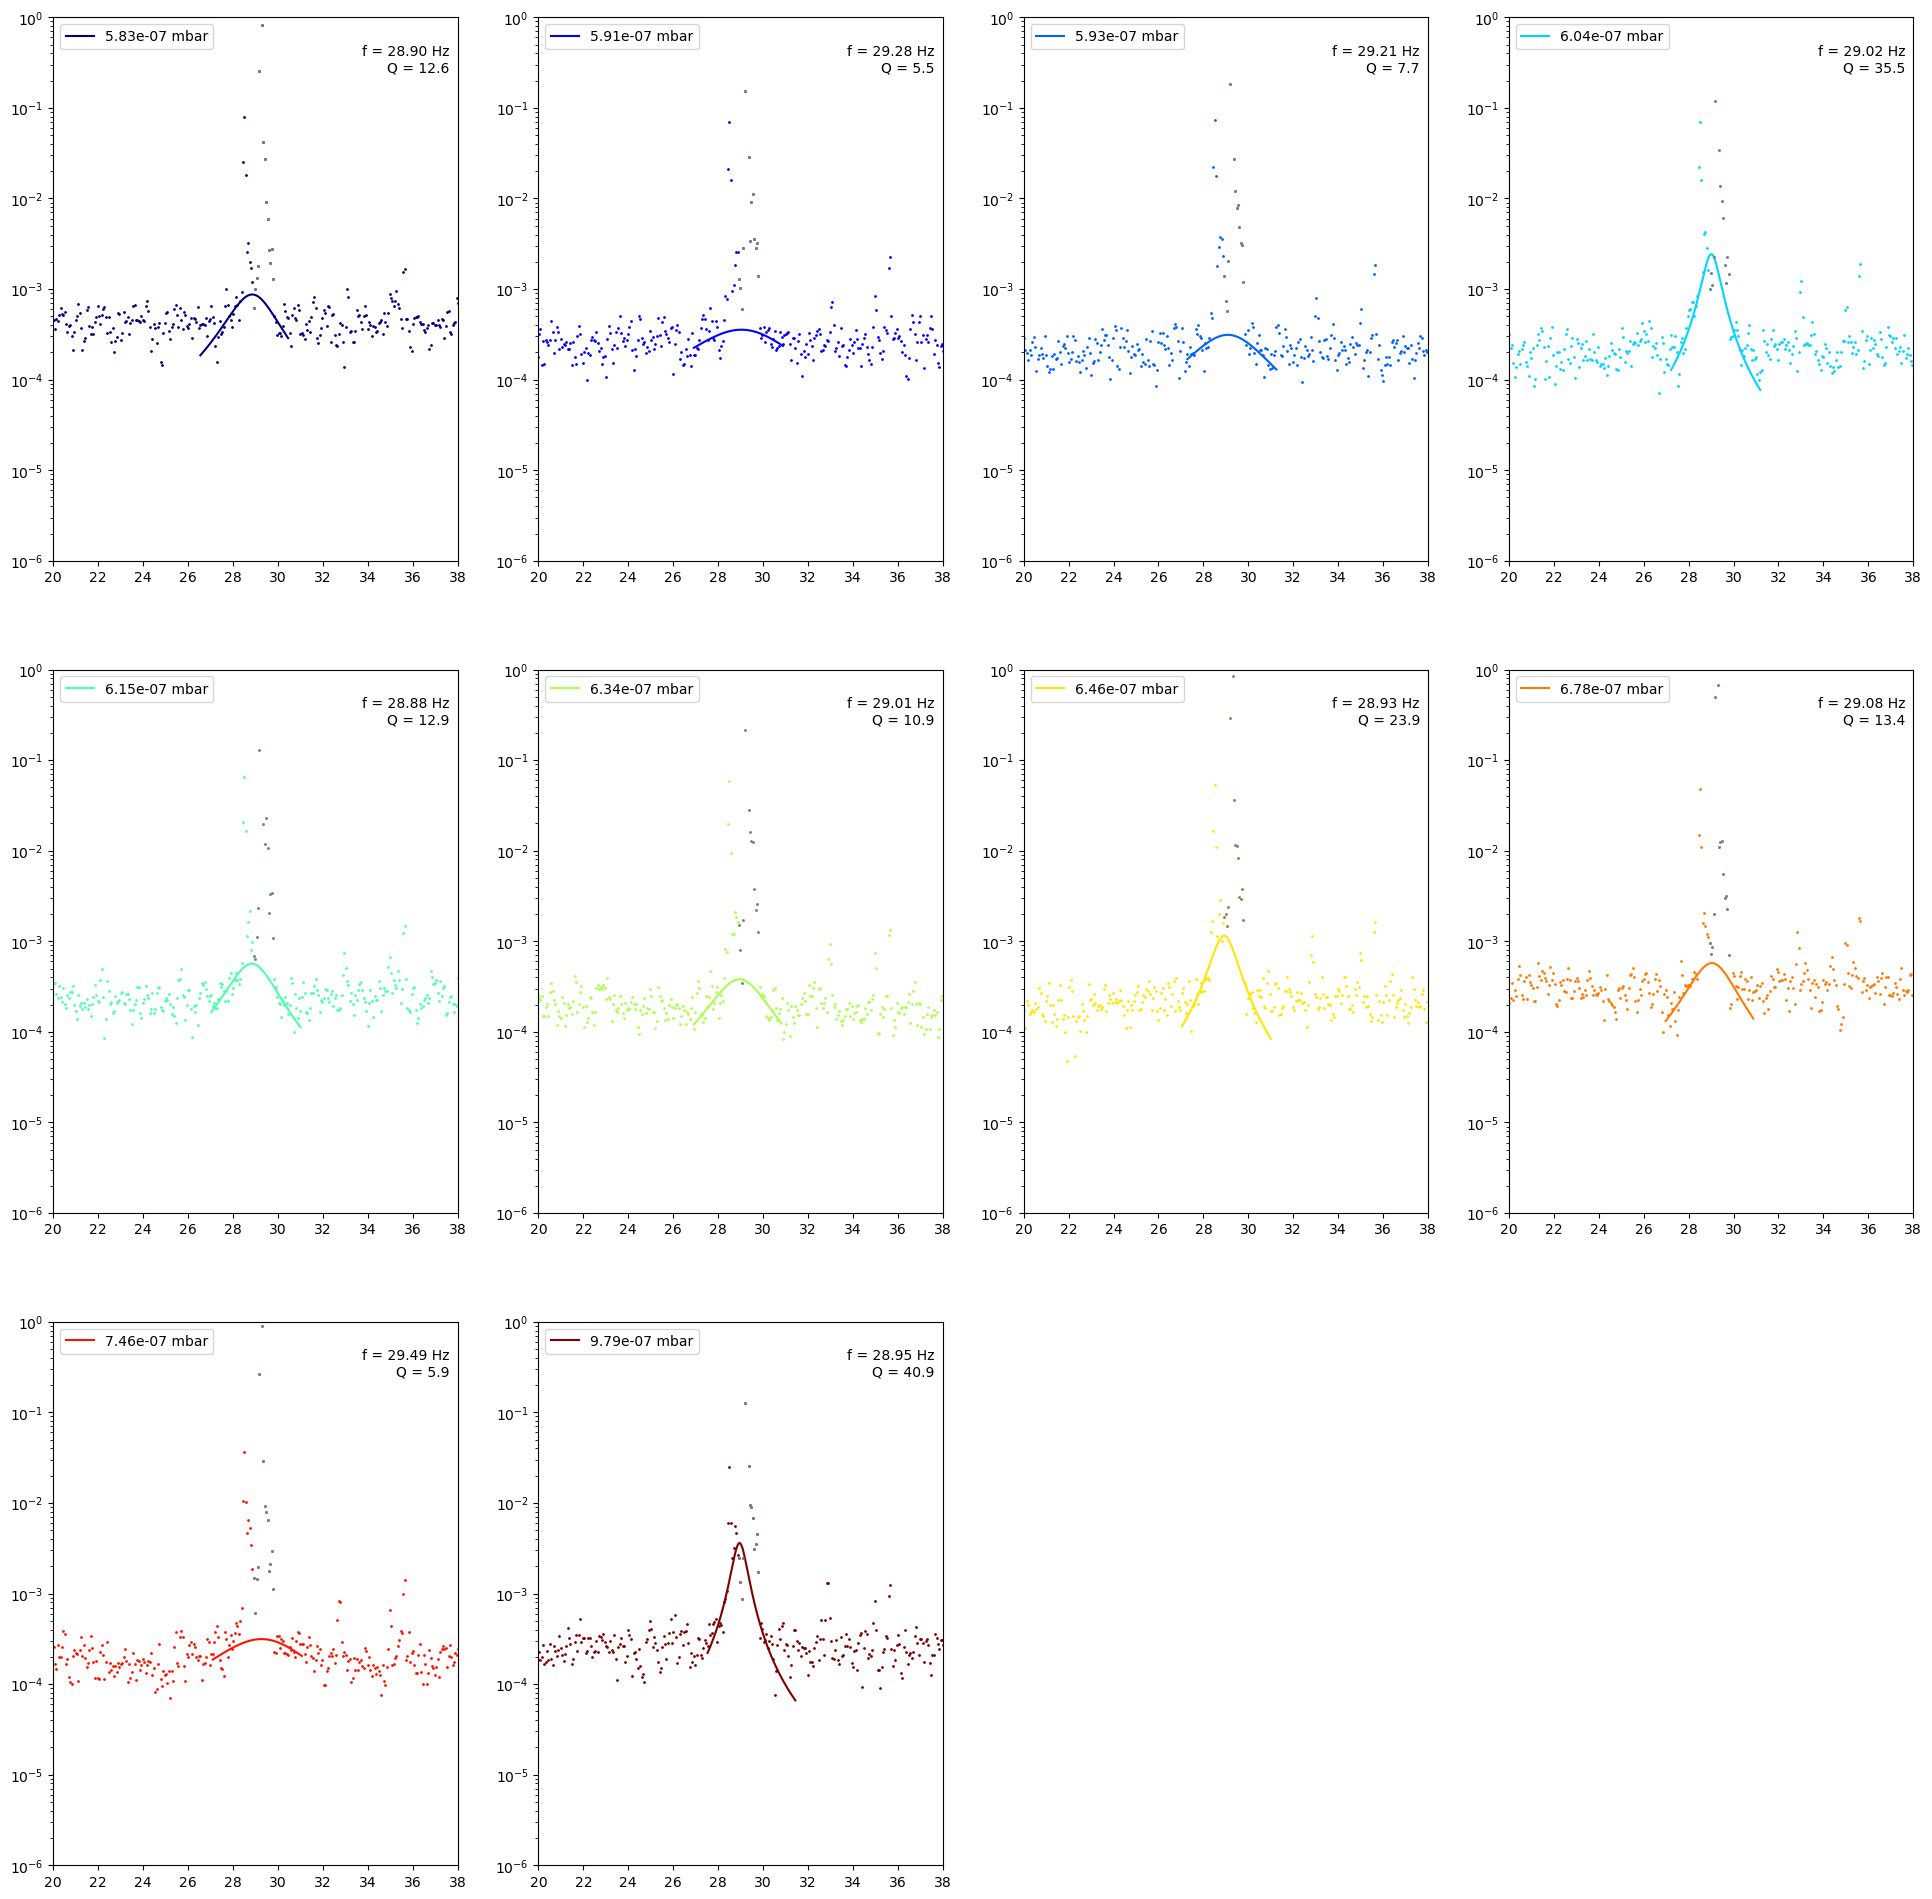

In [12]:
## incorporating Q-value into the fit
Q_values = []
Q_pressures = []
Q_flags = []

fig = plt.figure(figsize=(24,24))

noise_freqs = [[28.9,29.3],[29.3,29.8]] #freqs to exclude from the fit due to pump noise
bad_list= [4.12e-2]
plot_idx = 1
ncols = 4
nrows = int(len(pressure_files)/4) + 1
bp = None
for p, pf, c in zip(pressure_list, pressure_files, colors):
    if(p < 0.1):
        nperseg = 2**14
    else:
        nperseg = 2**13
    curr_psd_dict, curr_freqs = make_psd_from_file_list([pf])
    if curr_psd_dict is None or p in bad_list:
        continue

    ## set starting parameters for fit
    if bp is None:
        last_fit = [1e3, 29, 1]
        fit_range = [26.5, 30.5]
    else:
        last_fit = bp
        fit_range = [bp[1]-2, bp[1]+2]

    
    bp = fit_psd(curr_psd_dict, curr_freqs, fig, xlims=[20,38], make_plot=True, ch='y', lc=c, 
            fit_range = fit_range, noise_freqs=noise_freqs, subplot_idx=[nrows, ncols, plot_idx], 
            guess_params=last_fit, plot_guess=False, plot_label="%.2e mbar"%p)

    Q = bp[1] / (abs(bp[2]))  # Q =  w_0/gamma_0
    fit_flag = "good"
    if Q > 150 or Q < 10 or abs(bp[2]) < 0.05 or abs(bp[2]) > 3.0:
        fit_flag = "suspect"
    Q_values.append(Q)
    Q_pressures.append(p)
    Q_flags.append(fit_flag)
        
    # Add fit params as text on subplot
    plt.subplot(nrows, ncols, plot_idx)
    param_text = f"f = {bp[1]:.2f} Hz\nQ = {Q:.1f}"
    plt.text(0.98, 0.95, param_text, transform=plt.gca().transAxes,
    ha='right', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    plot_idx += 1


plt.show()

# ## make a colorbar with the pressure values
# from matplotlib.colors import Normalize
# from matplotlib.cm import ScalarMappable
# from matplotlib.colorbar import ColorbarBase
# norm = Normalize(vmin=np.log10(pressure_list.min()), vmax=np.log10(pressure_list.max()))
# sm = ScalarMappable(cmap='jet', norm=norm)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=fig.axes, orientation='vertical')
# cbar.set_label('Pressure (mbar)')
# ticks = np.log10(np.logspace(np.log10(pressure_list.min()), np.log10(pressure_list.max()), 8))
# cbar.set_ticks(ticks)
# cbar.set_ticklabels([f"{10**p:.1e}" for p in ticks])

plt.show()

/var/folders/pm/q9m_8qtd49d0qpf2b6nzw89h0000gn/T/ipykernel_1220/1858908463.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


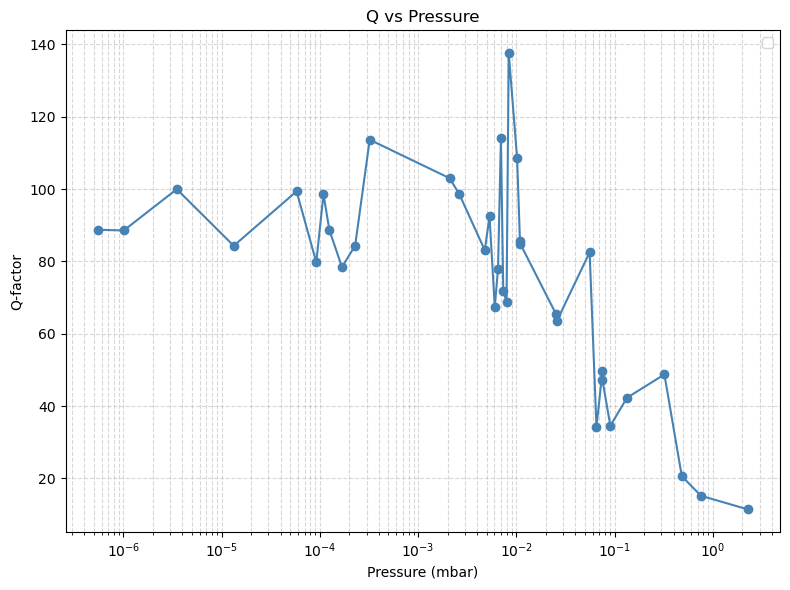

In [74]:
Q_values = np.array(Q_values)
Q_pressures = np.array(Q_pressures)
Q_flags = np.array(Q_flags)

good = Q_flags == "good"
suspect = Q_flags == "suspect"

plt.figure(figsize=(8,6))
plt.semilogx(Q_pressures[good], Q_values[good], color='steelblue', marker='o', linestyle='-')
#plt.semilogx(Q_pressures[suspect], Q_values[suspect], 'ro', label='Suspect fits')
plt.xlabel("Pressure (mbar)")
plt.ylabel("Q-factor")
plt.title("Q vs Pressure")
# plt.title("Q vs Pressure with Fit Flags")
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

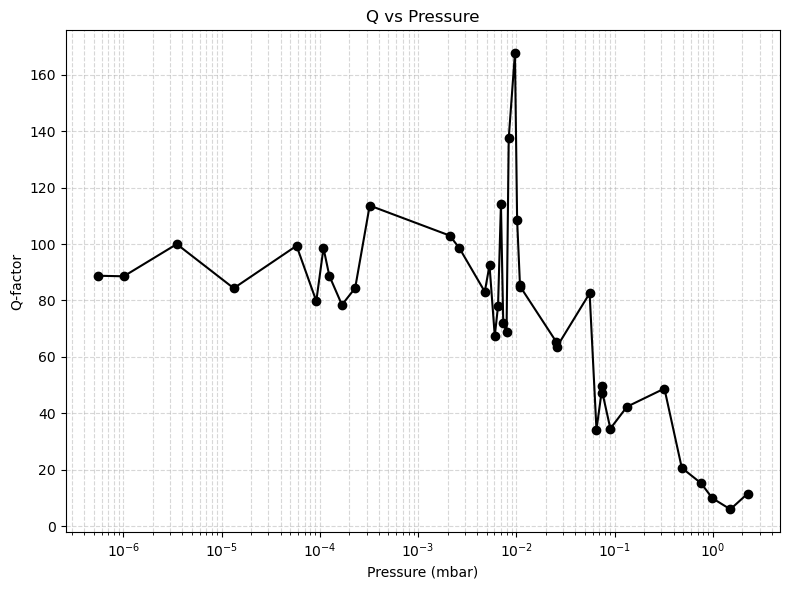

In [66]:
# Plot Q vs Pressure
plt.figure(figsize=(8,6))
plt.semilogx(Q_pressures, Q_values, 'o-', color='black', markersize=6)
plt.xlabel("Pressure (mbar)")
plt.ylabel("Q-factor")
plt.title("Q vs Pressure")
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [47]:
data = np.load(pressure_files[-1])

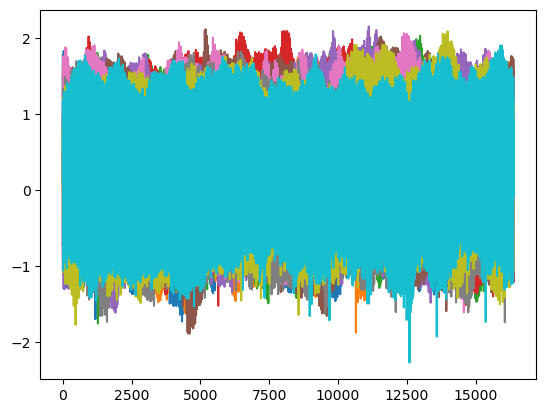

In [48]:
plt.figure()
plt.plot(data['data'][:,:,1].T)

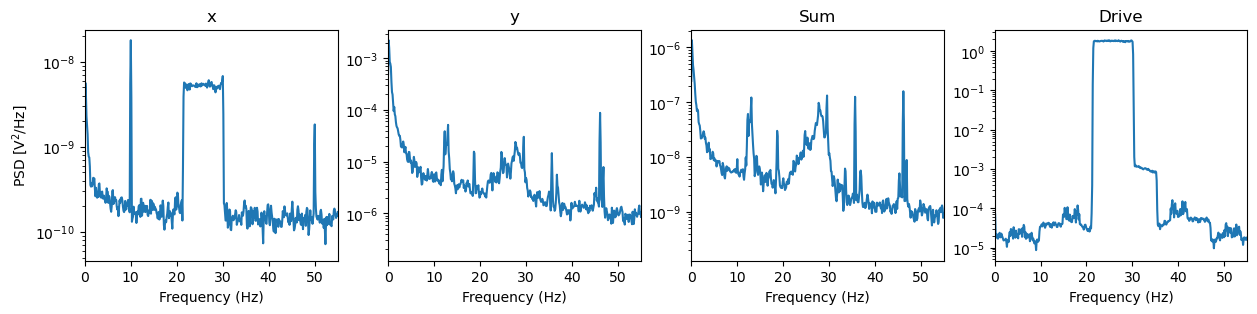

In [691]:
curr_psd_dict, curr_freqs = make_psd_from_file_list([pressure_files[-1]])

fig = plt.figure(figsize=(15,3))
plot_psd_dict(curr_psd_dict, curr_freqs, fig)

In [59]:
from scipy.signal import find_peaks

def fit_psd(psd, freqs, fig=None, make_plot=False, ch='y', xlims=[0, 55], 
            lc=None, ylims=[1e-6,1], fit_range=None, noise_freqs=[], 
            subplot_idx = [], guess_params=None, plot_guess=False,
            plot_label=""):

    bad_points = np.zeros(len(freqs), dtype=bool)
    for nf in noise_freqs:
        bad_points |= ((freqs > nf[0]) & (freqs < nf[1]))

    # Default fit range
    if fit_range is None:
        fit_range = [26, 31]

    fit_idx = ((freqs > fit_range[0]) & (freqs < fit_range[1])) & ~bad_points
    fit_freqs = freqs[fit_idx]
    fit_psd_vals = psd[ch][fit_idx]

    # Use peak finder for initial guess
    peaks, props = find_peaks(fit_psd_vals, height=np.max(fit_psd_vals)*0.3)
    if len(peaks) > 0:
        peak_idx = peaks[0]
        f0_guess = fit_freqs[peak_idx]
        A_guess = props['peak_heights'][0]
        gamma_guess = 1.0
        guess_params = [A_guess, f0_guess, gamma_guess]
    else:
        guess_params = [1e3, 29.0, 1.0]

    if not plot_guess:
        try:
            bp, bcov = curve_fit(
                lorentzianPSD, fit_freqs, fit_psd_vals,
                p0=guess_params, sigma=np.maximum(fit_psd_vals, 1e-12),
                bounds=([0, 25, 0.01], [np.inf, 35, 10.0])
            )
        except RuntimeError:
            print(f"Fit failed for {plot_label}")
            return None
    else:
        bp = guess_params

    # Optional: refine fit_range and rerun once (not recursive)
    if not plot_guess and fit_range is None:
        refined_range = [bp[1] - 2, bp[1] + 2]
        return fit_psd(psd, freqs, fig, make_plot, ch, xlims, lc, ylims,
                       fit_range=refined_range, noise_freqs=noise_freqs,
                       subplot_idx=subplot_idx, guess_params=bp,
                       plot_guess=False, plot_label=plot_label)

    # Plotting
    if make_plot:
        plt.figure(fig.number)
        ms = 1

        if subplot_idx:
            plt.subplot(subplot_idx[0], subplot_idx[1], subplot_idx[2])

        freq_vals = np.linspace(fit_range[0], fit_range[1], 1000)
        plt.semilogy(freqs, psd[ch], 'o', color=lc, markersize=ms)
        plt.semilogy(freq_vals, lorentzianPSD(freq_vals, *bp), color=lc, label=plot_label)
        plt.semilogy(freqs[bad_points], psd[ch][bad_points], 'o', color='gray', markersize=ms)
        plt.xlim(xlims)
        plt.ylim(ylims)
        if plot_label:
            plt.legend()

    return bp